# TODO:
- [x] load data
- [x] create regression predictions and curves
- [x] calculate covariance
- [x] combine into markowitz model
- [x] use wsm ecm with quadratic solver to create pareto from
- [x] compare efficiency of those methods for finding unique pareto solutions (visualize fronts)
- [ ] select best prediction 

### Dependencies


In [15]:
import numpy as np
import glob
import sklearn
import matplotlib.pyplot as plt
import cvxopt
cvxopt.solvers.options['show_progress'] = False


### Load Data

Results in `stocks` dictionary

In [16]:
def load_stock_data(filename):
    with open(filename, "r") as file:
        name : str
        n : int
        datapoints = []
        for i, line in enumerate(file):
            line = line.strip()
            if i == 0:
                name = line
            elif i == 1:
                n = int(line)
            else:
                _, point = line.split(" ")
                point = float(point)
                datapoints.append(point)
        assert(len(datapoints) == n)
        return name, np.array(datapoints)

In [33]:
stocks = {}
for stock_filename in glob.glob("bundle1/*.txt"):
    name, datapoints = load_stock_data(stock_filename)
    stocks[name] = datapoints
print(f"Loaded {len(stocks)} stocks")

Loaded 20 stocks


### Regression on Log Returns
Results in `stocks_log_returns` and `stocks_predicted_log_returns` dictionaries

In [ ]:
def linear_regression_prediction(datapoints, n_past_samples, horizon=100):
    log_returns = np.diff(np.log(datapoints))
    x = np.arange(n_past_samples, len(log_returns)).reshape(-1, 1)
    reg = sklearn.linear_model.LinearRegression().fit(x, log_returns[n_past_samples:])
    fitted = reg.predict(x)
    err = np.std(log_returns[n_past_samples:] - fitted)
    px = np.arange(len(log_returns), len(log_returns) + horizon).reshape(-1, 1)
    predicted_log_returns = reg.predict(px)
    return log_returns, predicted_log_returns, err

def ridge_regression_prediction(datapoints, n_past_samples, horizon=100, alpha=1.0):
    log_returns = np.diff(np.log(datapoints))
    x = np.arange(n_past_samples, len(log_returns)).reshape(-1, 1)
    reg = sklearn.linear_model.Ridge(alpha=alpha).fit(x, log_returns[n_past_samples:])
    fitted = reg.predict(x)
    err = np.std(log_returns[n_past_samples:] - fitted)
    px = np.arange(len(log_returns), len(log_returns) + horizon).reshape(-1, 1)
    predicted_log_returns = reg.predict(px)
    return log_returns, predicted_log_returns, err


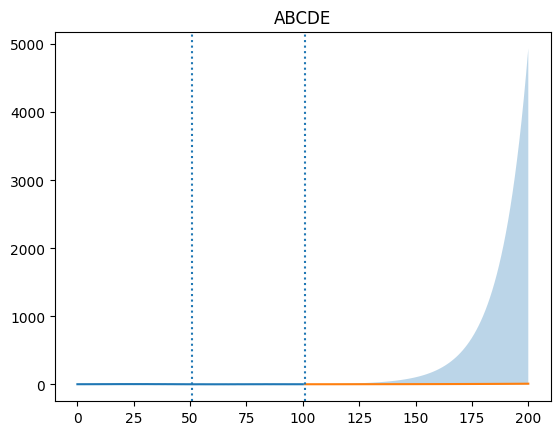

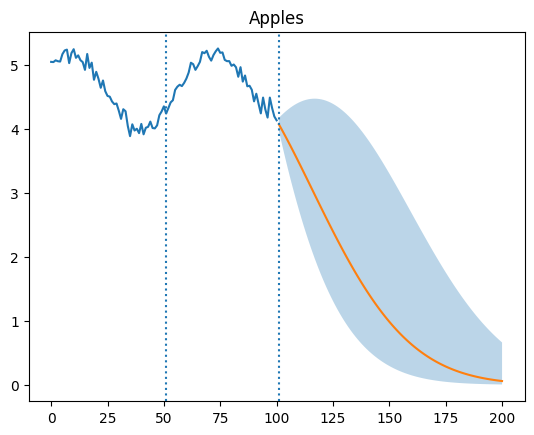

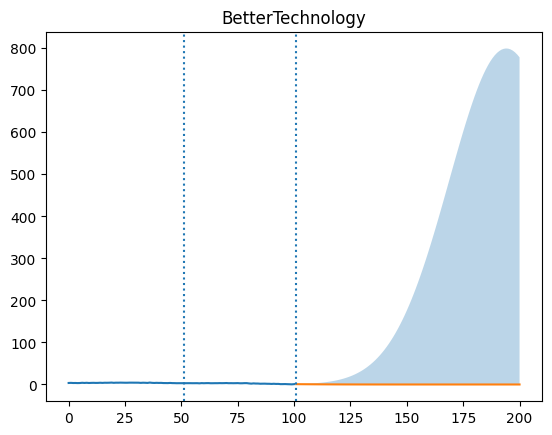

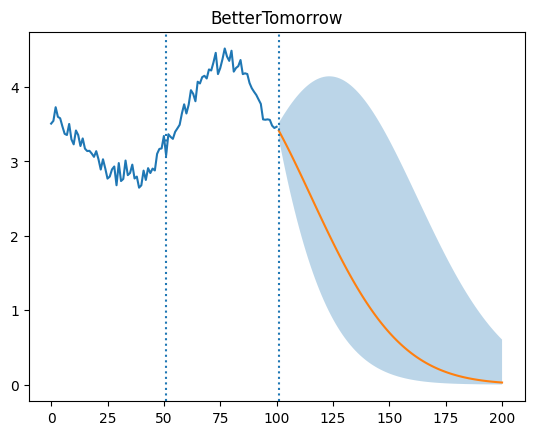

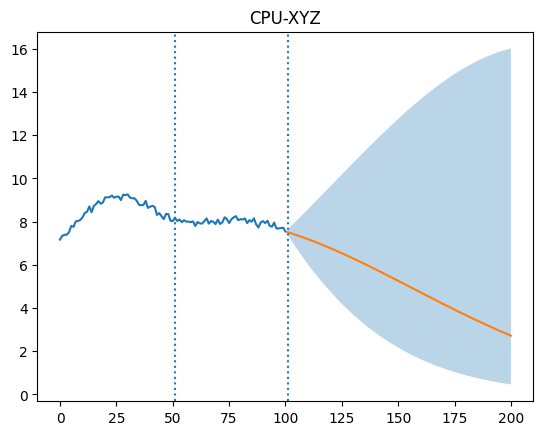

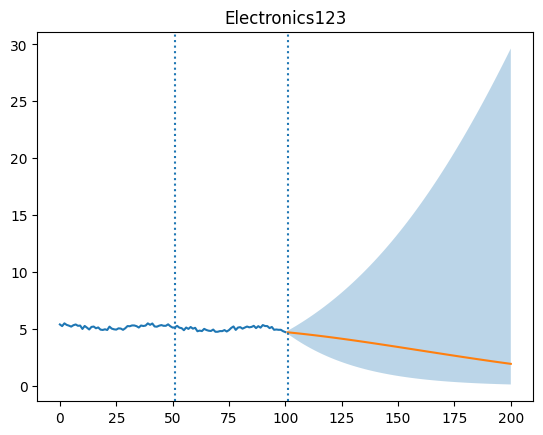

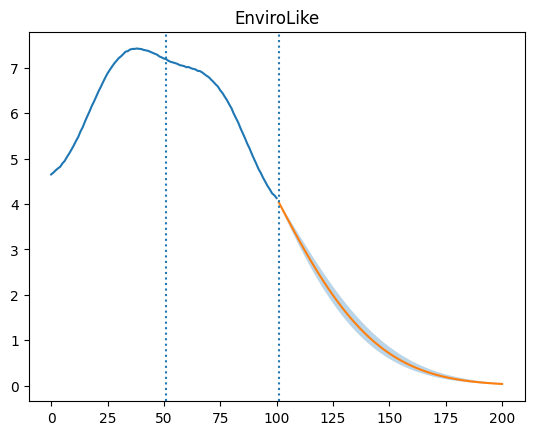

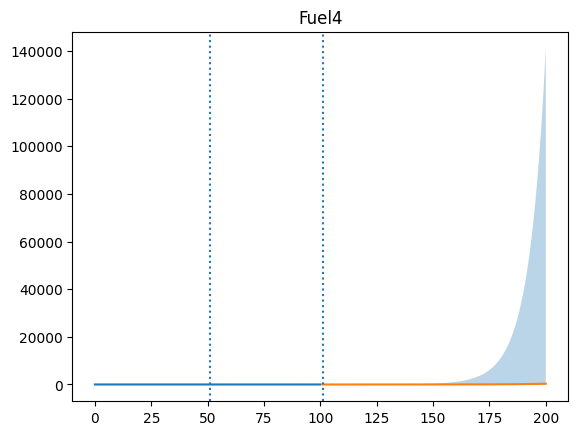

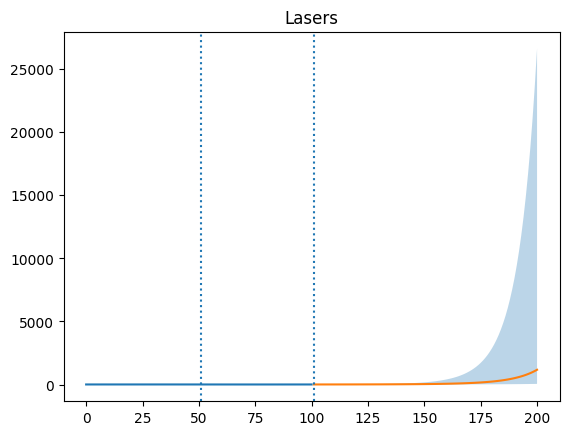

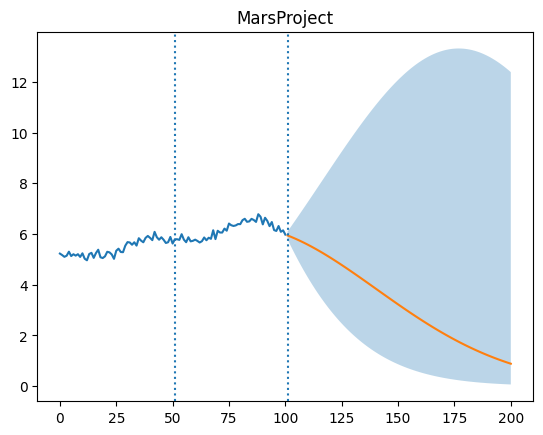

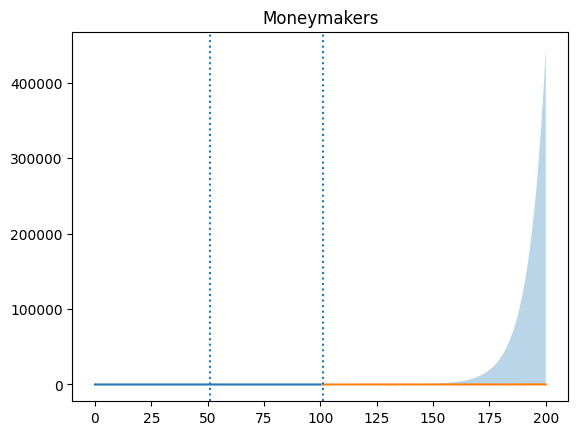

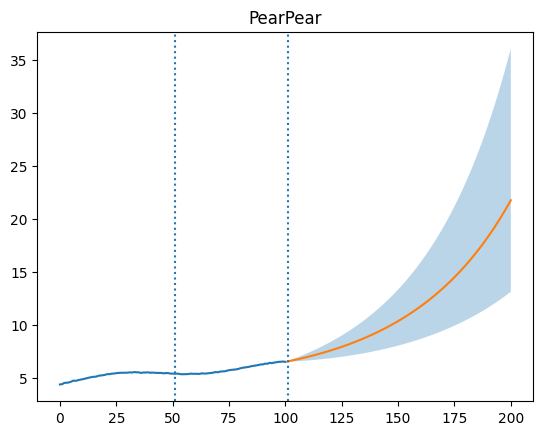

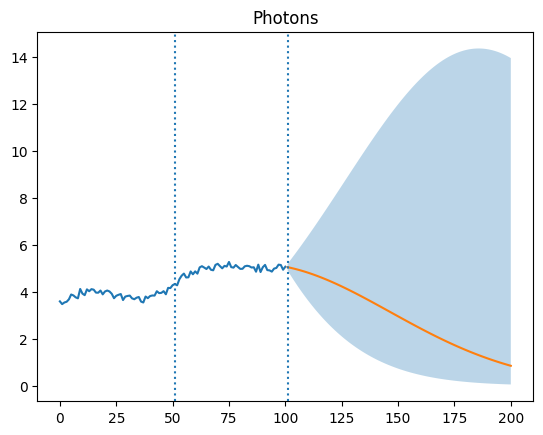

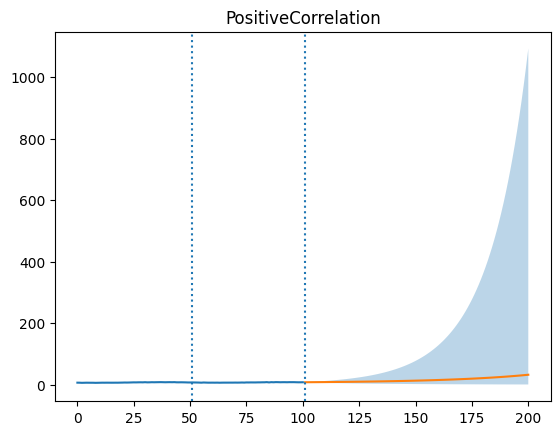

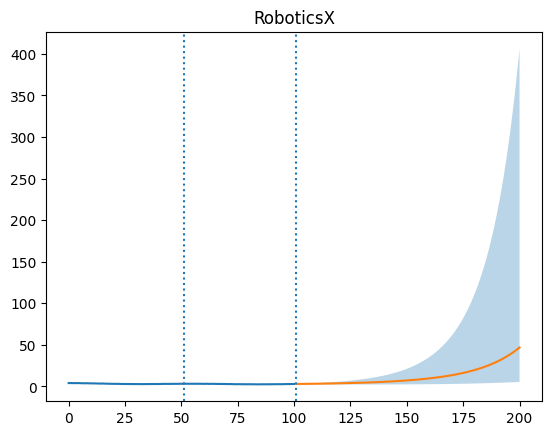

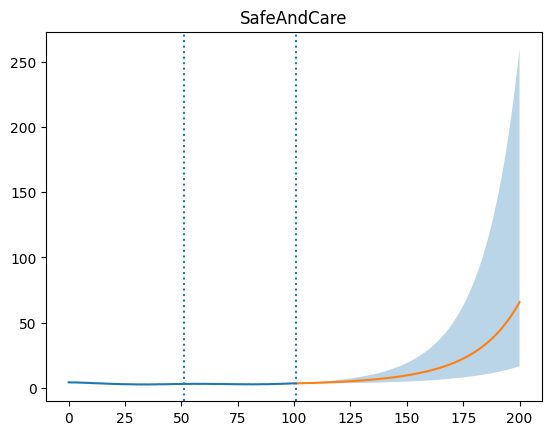

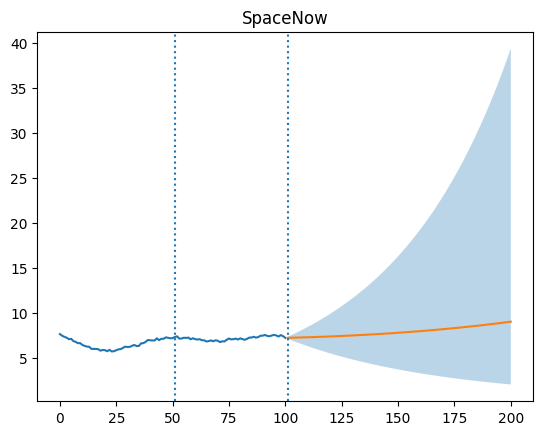

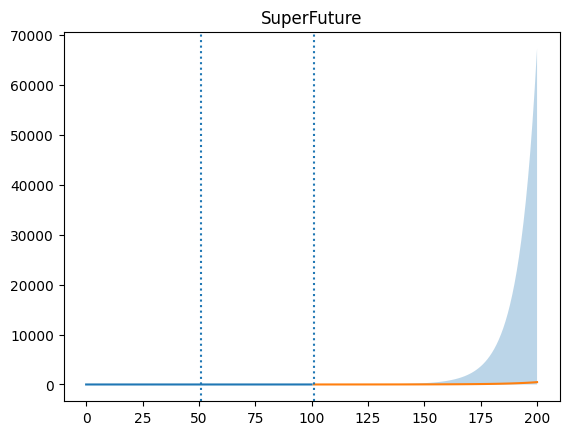

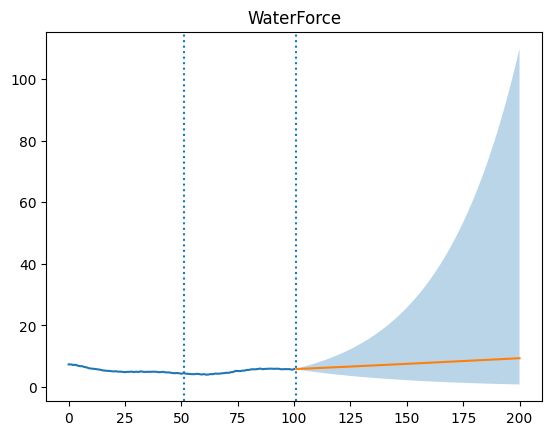

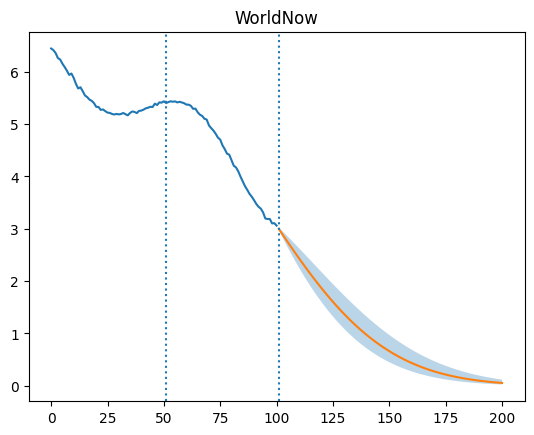

In [35]:
stocks_log_returns = {}
stocks_predicted_log_returns = {}
forecast_horizon = 100
for stock_name, stock_datapoints in stocks.items():
    n_past_samples = 50
    log_returns, predicted_log_returns, err = linear_regression_prediction(
        stock_datapoints, n_past_samples=n_past_samples, horizon=forecast_horizon
    )
    stocks_log_returns[stock_name] = log_returns
    stocks_predicted_log_returns[stock_name] = np.sum(predicted_log_returns)
    
    x = np.arange(len(stock_datapoints))
    plt.plot(x, stock_datapoints)
    
    px = np.arange(len(stock_datapoints), len(stock_datapoints) + forecast_horizon)
    cumulative_predicted_log_returns = np.cumsum(predicted_log_returns)
    predicted_prices = stock_datapoints[-1] * np.exp(cumulative_predicted_log_returns)
    lower_prices = stock_datapoints[-1] * np.exp(np.cumsum(predicted_log_returns - err))
    upper_prices = stock_datapoints[-1] * np.exp(np.cumsum(predicted_log_returns + err))
    
    plt.plot(px, predicted_prices)
    plt.axvline(n_past_samples + 1, linestyle="dotted")
    plt.axvline(len(stock_datapoints), linestyle="dotted")
    plt.fill_between(px, lower_prices, upper_prices, alpha=0.3)
    plt.title(stock_name)
    plt.show()


In [36]:
print(stocks_predicted_log_returns)

{'ABCDE': np.float64(1.2060663623184018), 'Apples': np.float64(-4.248934569738207), 'BetterTechnology': np.float64(-14.304991155169112), 'BetterTomorrow': np.float64(-4.841333267652561), 'CPU-XYZ': np.float64(-1.0194415868978797), 'Electronics123': np.float64(-0.8916346382266106), 'EnviroLike': np.float64(-4.724261137600404), 'Fuel4': np.float64(4.305894131679782), 'Lasers': np.float64(5.208272968466625), 'MarsProject': np.float64(-1.9128337292104922), 'Moneymakers': np.float64(2.7736752015159807), 'PearPear': np.float64(1.2069932735321163), 'Photons': np.float64(-1.7878690448462105), 'PositiveCorrelation': np.float64(1.3784064276081196), 'RoboticsX': np.float64(2.7695283895864495), 'SafeAndCare': np.float64(2.9536209578764208), 'SpaceNow': np.float64(0.2213576145930833), 'SuperFuture': np.float64(4.967559609978299), 'WaterForce': np.float64(0.47887411757126447), 'WorldNow': np.float64(-4.021407474696282)}


### Covariance

Results in `stocks_covariance` matrix and `stocks_expected_return` vector built for 100-day log returns

In [37]:
m = []
stocks_expected_return = []
for stock in stocks:
    m.append(stocks_log_returns[stock])
    stocks_expected_return.append(stocks_predicted_log_returns[stock])
m = np.array(m)
stocks_covariance = np.cov(m) * forecast_horizon
stocks_expected_return = np.array(stocks_expected_return)

### Solve QP with Weighted Sum Method

In [38]:
def evaluate_solution(weights, expected_return, covariance_matrix):
    return np.sum(weights * (expected_return)), weights.T @ covariance_matrix @ weights

def wsm_solve(risk_weight, expected_return, covariance_matrix, normalize = True):
    n_factor_risk = 1.0
    n_factor_return = 1.0
    if normalize:
        wreturn = wsm_solve(0.0, expected_return, covariance_matrix, normalize=False)
        wrisk = wsm_solve(1.0, expected_return, covariance_matrix, normalize=False)
        max_return, min_risk = evaluate_solution(wreturn, expected_return, covariance_matrix)
        min_return, max_risk = evaluate_solution(wrisk, expected_return, covariance_matrix)
        eps = 1e-10
        n_factor_return = 1 / max(max_return - min_return, eps)
        n_factor_risk = 1 / max(max_risk - min_risk, eps)
    n = len(expected_return)
    Q = cvxopt.matrix(2 * risk_weight * n_factor_risk * covariance_matrix) # we have to flip for correct column layout I think
    c = cvxopt.matrix((1 - risk_weight) * expected_return * -1 * n_factor_return)
    b = cvxopt.matrix(1.0)
    A = cvxopt.matrix(np.ones(shape=(1,n)))

    G = cvxopt.matrix(-np.eye(n))
    h = cvxopt.matrix(np.zeros(n))

    sol = cvxopt.solvers.qp(Q, c, G, h, A, b)
    weights = np.array(sol['x']).flatten()
    return weights



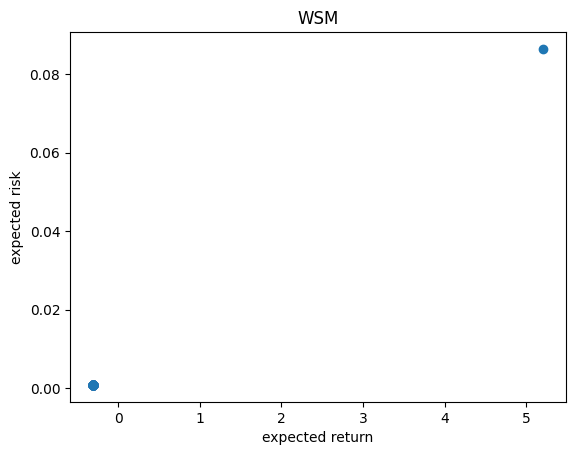

In [39]:
n_samples = 100
wsm_x_returns = []
wsm_y_risks = []
wsm_solutions = []
for i in range(n_samples + 1):
    wcm_weight = 1 / n_samples * i
    w = wsm_solve(wcm_weight, stocks_expected_return, stocks_covariance)
    ereturn, risk = evaluate_solution(w, stocks_expected_return, stocks_covariance)
    wsm_x_returns.append(ereturn)
    wsm_y_risks.append(risk)
    wsm_solutions.append(w)
wsm_x_returns = np.array(wsm_x_returns)

plt.scatter(wsm_x_returns, wsm_y_risks)
plt.xlabel("expected return")
plt.ylabel("expected risk")
plt.title("WSM")
plt.show()

### epsilon constrained method

In [40]:
def ecm_solve(epsilon, expected_return, covariance_matrix):
    n = len(expected_return)
    Q = cvxopt.matrix(2 * covariance_matrix) # we have to flip for correct column layout I think
    c = cvxopt.matrix(np.zeros(n))
    b = cvxopt.matrix(1.0)
    A = cvxopt.matrix(np.ones(shape=(1,n)))

    G = cvxopt.matrix(np.vstack((-expected_return,-np.eye(n))))
    h = np.zeros(n+1)
    h[0] = -epsilon
    h = cvxopt.matrix(h)

    sol = cvxopt.solvers.qp(Q, c, G, h, A, b)
    weights = np.array(sol['x']).flatten()
    return weights


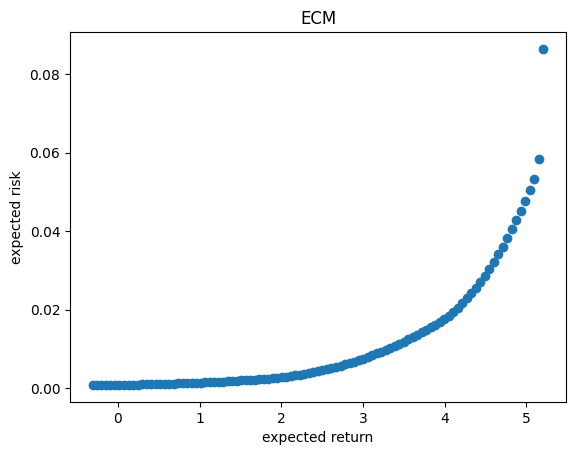

In [42]:
threshold_step = (np.max(wsm_x_returns)-np.min(wsm_x_returns))/n_samples
ecm_x_returns = []
ecm_y_risks = []
for i in range(n_samples + 1):
    t = i * threshold_step + np.min(wsm_x_returns)
    w = ecm_solve(t, stocks_expected_return, stocks_covariance)
    ereturn, risk = evaluate_solution(w, stocks_expected_return, stocks_covariance)
    ecm_x_returns.append(ereturn)
    ecm_y_risks.append(risk)
plt.scatter(ecm_x_returns, ecm_y_risks)
plt.xlabel("expected return")
plt.ylabel("expected risk")
plt.title("ECM")
plt.show()
